# MLL Project Assignment

This project is part of the course Datan käsittely ja koneoppiminen. The goal of the project is to apply machine learning and data mining methods to a real dataset while following the CRISP-DM (Cross Industry Standard Process for Data Mining) framework. The project covers the full workflow from starting at defining the problem and research questions and continuing through data preparation, modeling, evaluation, and conclusions.

## Business Understanding

In this project we aim to build a movie recommendation system using a dataset of real movie ratings. The goal is to recommend movies to users based on their preferences and the preferences of similar users. Movie recommendation systems are widely used in streaming services and online platforms to help users discover relevant content and enhance their viewing experience.

The focus of this project is to build a user-based movie recommendation model. The model aims to recommend movies to a user based on the preferences of other users who have shown similar rating patterns. This type of recommendation system is known as collaborative filtering.

### Goals

The main goal for this project is to build a movie recommendation system that could work as a base for a real-world streaming service or online platform for searching movies that users might like. The recommendation system should be able to recommend movies to users based on their preferences and the preferences of similar users.

### Objectives

- Explore and understand the structure and characteristics of the movie ratings dataset
- Prepare and preprocess the data for machine learning tasks
- Identify similarities between users based on their movie ratings
- Implement a user-based collaborative filtering recommendation algorithm
- Generate movie recommendations for users based on similar users’ preferences
- Evaluate how well the recommendation approach works using suitable metrics

### Research questions

- Can meaningful similarities between users be identified based on their movie rating behavior?
- How effectively can a user-based collaborative filtering model recommend movies to users?
- What types of movies are recommended to users based on the preferences of similar users?

## Data understanding

Our dataset is sourced from grouplens.org, which provides a collection of movie ratings and metadata. The dataset we are using is the "ml-latest-small" version, which contains a subset of the full dataset and is suitable for our project. Link to the dataset: https://grouplens.org/datasets/movielens/

In [1]:
# imports

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Reader, Dataset
from surprise import KNNBasic
from surprise import accuracy
from surprise.model_selection import train_test_split, cross_validate


Our dataset consists of two main files: movies.csv and ratings.csv. The movies.csv file contains information about the movies, including their unique identifiers (movieId), titles, and genres. The ratings.csv file contains user ratings for the movies, including user identifiers (userId), movie identifiers (movieId), ratings, and timestamps. To make things easier, we will merge these two datasets based on the movieId column, which is common to both datasets. This will allow us to have all the relevant information about movies and their ratings in a single DataFrame for further analysis and modeling.

In [2]:
# Load the datasets
movies = pd.read_csv('datasets/movies-small/ml-latest-small/movies.csv', sep=',')
ratings = pd.read_csv('datasets/movies-small/ml-latest-small/ratings.csv', sep=',')

# Merging the datasets based on the movieId column
movie_ratings = pd.merge(ratings, movies, on='movieId')

# Display the first 5 rows of the merged dataset
movie_ratings.head(5)

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Now the structure of the merged dataset is as follows:
- userId: Unique identifier for each user
- movieId: Unique identifier for each movie
- rating: The rating given by the user to the movie. We can also refer these ratings as stars (on a scale of 0.5 to 5.0)
- timestamp: The time when the rating was given (in Unix timestamp format)
- title: The title of the movie including the release year in parentheses e.g. "Toy Story (1995)"
- genres: The genres associated with the movie, separated by the pipe character (|) e.g. "Adventure|Animation|Children|Comedy|Fantasy"

Next, we will explore the dataset a bit further to understand its characteristics and identify any potential issues or insights that could inform our modeling approach. We will look at some of the basic statistics of the dataset and distributions of ratings among other things.

In [3]:
# Basic statistics about the movie ratings
print("Basic statistics about the movie ratings:")
print(f"Number of unique users: {ratings['userId'].nunique()}")
print(f"Number of unique movies: {movies['title'].nunique()}")
print(f"Total number of ratings: {ratings.shape[0]}")
print(f"Average rating: {ratings['rating'].mean():.2f}")
print("----------------------------------------")
print("Ratings per user and movie:")
print(f"The lowest amount of ratings given by a user: {movie_ratings.groupby('userId')['rating'].count().min()}")
print(f"The highest amount of ratings given by a user: {movie_ratings.groupby('userId')['rating'].count().max()}")
print(f"The average amount of ratings given by a user: {movie_ratings.groupby('userId')['rating'].count().mean():.2f}")
print(f"The lowest amount of ratings received by a movie: {movie_ratings.groupby('movieId')['rating'].count().min()}")
print(f"The highest amount of ratings received by a movie: {movie_ratings.groupby('movieId')['rating'].count().max()}")
print("The average amount of ratings received by a movie: {:.2f}".format(movie_ratings.groupby('movieId')['rating'].count().mean()))

Basic statistics about the movie ratings:
Number of unique users: 610
Number of unique movies: 9737
Total number of ratings: 100836
Average rating: 3.50
----------------------------------------
Ratings per user and movie:
The lowest amount of ratings given by a user: 20
The highest amount of ratings given by a user: 2698
The average amount of ratings given by a user: 165.30
The lowest amount of ratings received by a movie: 1
The highest amount of ratings received by a movie: 329
The average amount of ratings received by a movie: 10.37


We have 610 unique users and 9,737 unique movies in our dataset, with a total of 100,836 ratings. The average rating across all movies is approximately 3.50. The average rating being slightly above the midpoint of the rating scale suggests that users tend to give more positive ratings than negative ones, which could indicate a bias in the dataset. We will get a better understanding of this bias by looking at the distribution of ratings in the next step.

Additionally, the amount of ratings given by users varies widely, with some users giving only a few ratings while others have given many. Similarly, some movies have received a large number of ratings while others have received very few. This variability in the amount of ratings received by movies further highlights the potential bias in the dataset, as movies that have received more ratings might be more likely to be recommended by our model, while movies with fewer ratings might be overlooked. This is something we will need to consider when building our recommendation system, as it could affect the diversity and relevance of the recommendations we generate.

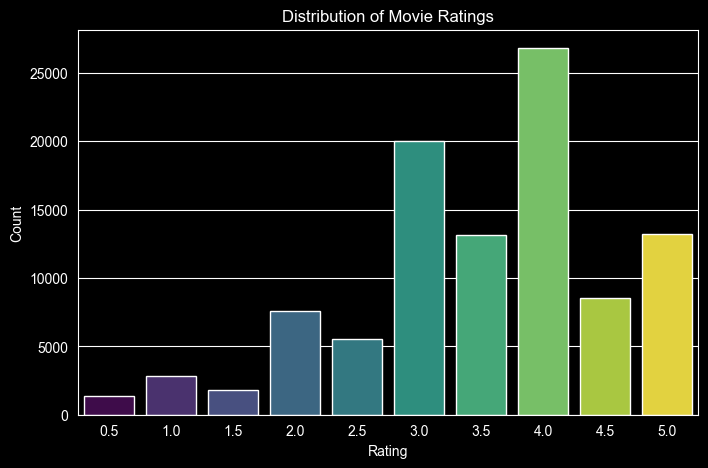

In [4]:
# Distribution of ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', hue='rating', data=ratings, palette='viridis', legend=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

The distribution of ratings shows that the most common rating is 4.0, followed by 3.0 and 5.0. The least common ratings are 0.5 and 1.5. This indicates that users tend to give ratings to movies that they liked, and they might leave out ratings for movies they did not like. This could lead to a bias in the dataset, as we might have more positive ratings than negative ones. This is something to keep in mind when building our recommendation model, as it might affect the performance and the types of recommendations we can generate.

For more detailed look at the ratings given by a specific user, you can use the code snippet below by changing the user_to_look variable to the desired user ID.

In [5]:
# Change user_to_look to the desired user ID to see their ratings
user_to_look = 600

if user_to_look in movie_ratings['userId'].unique():
    user_ratings = movie_ratings[movie_ratings['userId'] == user_to_look][['title', 'rating']]
else:
    user_ratings = f"User {user_to_look} not found in the dataset."

user_ratings

,title,rating
95101,Toy Story (1995),2.5
95102,Jumanji (1995),4.0
95103,Waiting to Exhale (1995),1.5
95104,Father of the Bride Part II (1995),2.5
95105,Sabrina (1995),3.5
...,...,...
95859,"Dark Knight, The (2008)",3.5
95860,Are You Scared? (2006),3.5
95861,Sex and the City (2008),2.5
95862,"Wrestler, The (2008)",3.0


## Data preparation

## Modeling

## Evaluation

## Deployment